### 8. Geographic Analysis: Revenue & Retention by Country

**Goal:**
Analyze how customer behavior differs across countries:
- Revenue contribution
- Customer retention
- Share of high-value customers

**Why it matters:**
Geographic differences reveal:
- Core vs secondary markets
- High-value regions
- Growth opportunities

In [147]:
# Loading necessary libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from local_config import *

engine = create_engine(
    f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
)

cohort_base = pd.read_sql("SELECT * FROM analytics.cohort_analysis_base", engine)

In [ ]:
# Data Preparation for Cohort Analysis
cohort_base['order_month'] = pd.to_datetime(cohort_base['order_month'])
cohort_base['cohort_month'] = pd.to_datetime(cohort_base['cohort_month'])

cohort_base['month_number'] = (
    (cohort_base['order_month'].dt.year * 12 + cohort_base['order_month'].dt.month) -
    (cohort_base['cohort_month'].dt.year * 12 + cohort_base['cohort_month'].dt.month)
)

In [ ]:
# ----------------------------
# Revenue by Country
# ----------------------------
revenue_by_country = (
    cohort_base
    .groupby('country')
    .agg(
        country_revenue=('order_revenue', 'sum'),
        country_customers=('customer_id', 'nunique')
    )
    .reset_index()
    .sort_values(by='country_revenue', ascending=False)
)

# Metrics
revenue_by_country['revenue_share'] = (
    revenue_by_country['country_revenue'] / revenue_by_country['country_revenue'].sum()
)

revenue_by_country['revenue_per_customer'] = (
    revenue_by_country['country_revenue'] / revenue_by_country['country_customers']
)

top10 = revenue_by_country.head(10)

/var/folders/zy/ggh_5ccd5q74n976swz5d6f80000gn/T/ipykernel_74737/1790248855.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


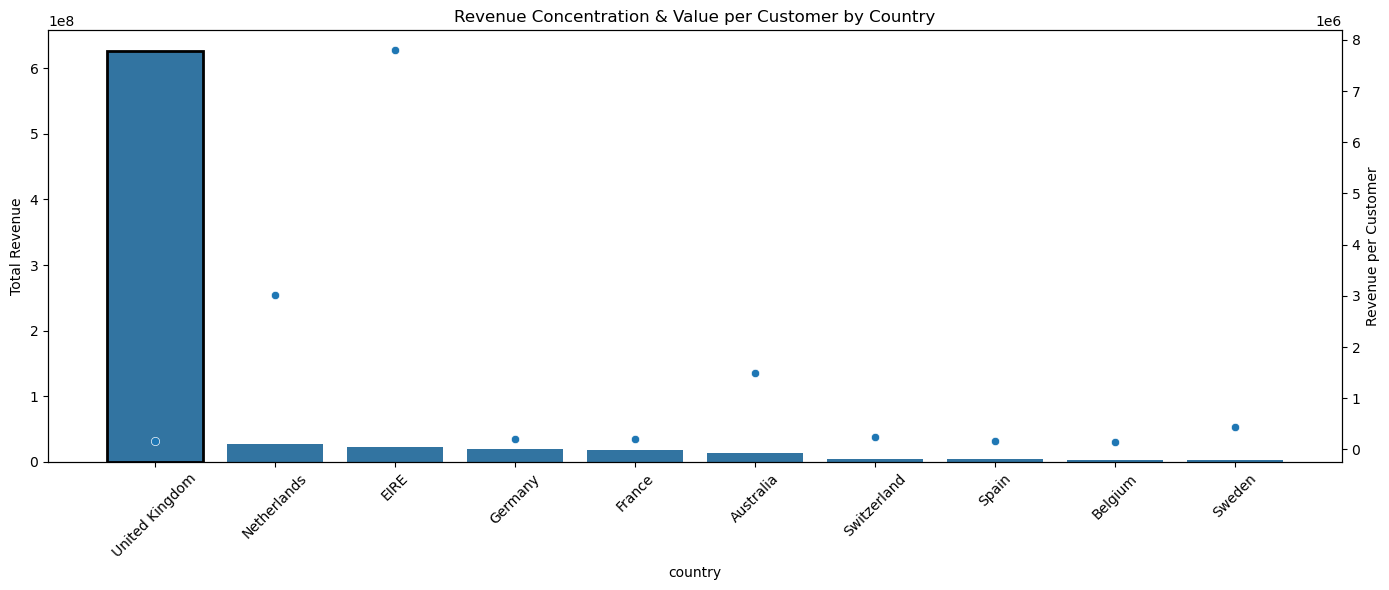

In [136]:
plt.figure(figsize=(14, 6))

# Revenue bars
ax = sns.barplot(
    data=top10,
    x='country',
    y='country_revenue'
)

# Highlight UK
for i, country in enumerate(top10['country']):
    if country == 'United Kingdom':
        ax.patches[i].set_edgecolor('black')
        ax.patches[i].set_linewidth(2)

# Secondary axis for revenue per customer
ax2 = ax.twinx()
sns.scatterplot(
    data=top10,
    x='country',
    y='revenue_per_customer',
    ax=ax2
)

# Formatting
ax.set_ylabel('Total Revenue')
ax2.set_ylabel('Revenue per Customer')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.title('Revenue Concentration & Value per Customer by Country')
plt.tight_layout()
plt.show()

### Revenue Distribution by Country

**1. The United Kingdom dominates the business**
- ~90% of customers
- ~82% of total revenue

**Insight:**  
The business is heavily concentrated in a single core market (UK), which drives the majority of both user base and revenue.

**2. Other countries contribute marginal revenue share**
- Each country outside the UK contributes <4% of total revenue

**Insight:**  
International markets are underdeveloped in terms of scale.

**3. Strong revenue-per-customer disparities across countries**
- EIRE: ~$7.8M per customer
- Netherlands: ~$3.0M per customer
- Australia: ~$1.5M per customer

**Insight:**  
Some smaller markets generate extremely high revenue per customer, indicating:
- presence of large buyers (B2B / bulk)
- or strong high-value customer segments

**4. Data skew from very small samples**
- EIRE (3 customers), Netherlands (9 customers)

**Insight:**  
Extremely high revenue per customer in these countries is likely driven by a few outliers rather than consistent behavior.

In [137]:
# ----------------------------
# Customer Segmentation
# ----------------------------
revenue_by_customer = cohort_base.groupby('customer_id')['order_revenue'].sum()
threshold = revenue_by_customer.quantile(0.7)

cohort_base['customer_segment'] = np.where(
    cohort_base['customer_id'].isin(revenue_by_customer[revenue_by_customer >= threshold].index),
    'High-Value',
    'Regular'
)

# Unique customer-country mapping
customer_base = cohort_base.drop_duplicates(
    subset=['customer_id', 'country']
)[['customer_id', 'country', 'customer_segment']]

In [139]:
# Aggregation for high-value customer share
high_value_share = (
    customer_base
    .groupby('country')
    .agg(
        total_customers=('customer_id', 'nunique'),
        high_value_customers=('customer_segment', lambda x: (x == 'High-Value').sum())
    )
)

high_value_share['high_value_share'] = (
    high_value_share['high_value_customers'] / high_value_share['total_customers']
)

high_value_share = high_value_share.reset_index()

top10_hv = top10[['country']].merge(high_value_share, on='country')

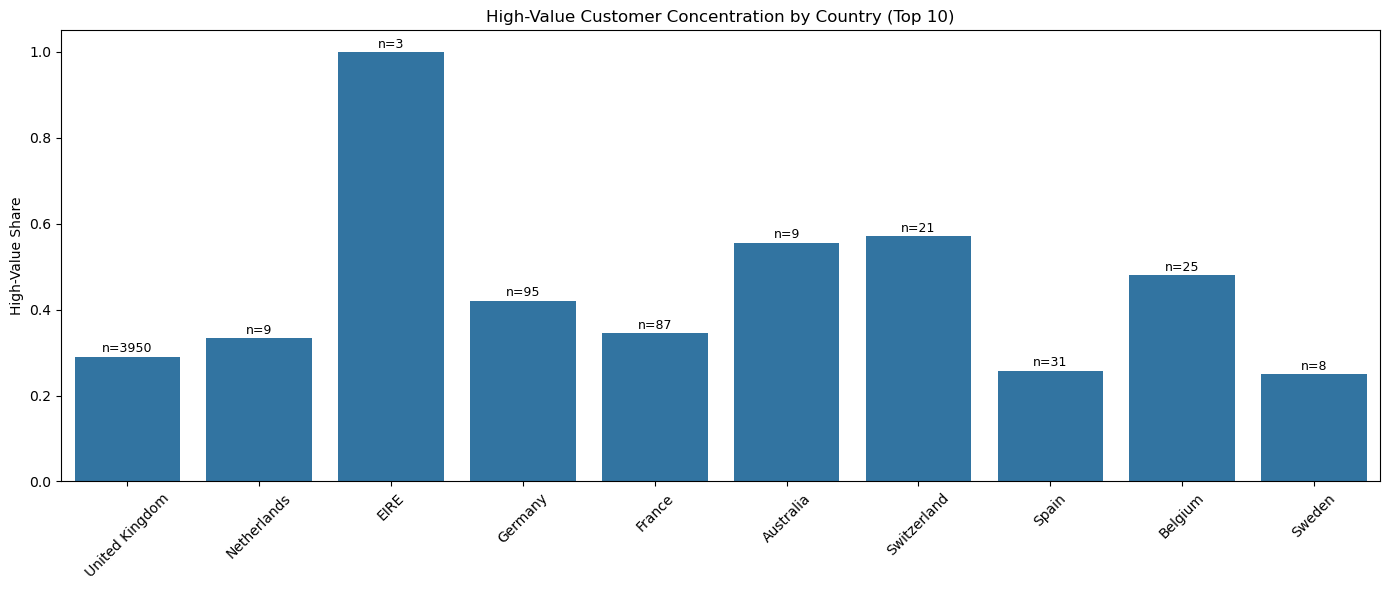

In [142]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=top10_hv,
    x='country',
    y='high_value_share'
)

# Add customer counts
for i, row in top10_hv.iterrows():
    ax.text(i, row['high_value_share'] + 0.01,
            f"n={int(row['total_customers'])}",
            ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.ylabel('High-Value Share')
plt.xlabel('')
plt.title('High-Value Customer Concentration by Country (Top 10)')
plt.tight_layout()
plt.show()

### High-Value Customer Distribution by Country

**1. High-value customers are not evenly distributed**
- UK: ~29%
- Germany: ~42%
- Switzerland: ~57%
- Australia: ~56%

**Insight:**  
Some smaller markets have a significantly higher concentration of high-value customers.


**2. Smaller countries show higher high-value ratios**
- EIRE: 100% (3/3 customers)
- Switzerland: 57%
- Australia: 56%

**Insight:**  
These markets may be dominated by a few high-spending customers rather than a broad customer base.


**3. The UK has lower high-value share despite dominance**
- Only ~29% high-value customers

**Insight:**  
The UK is a mass-market with a large base of regular (lower-value) customers.


**4. Sample size limitation**
- High-value share in small countries is sensitive to very few users

**Insight:**  
Results for small markets should be interpreted cautiously due to low sample size.

In [143]:
# ----------------------------
# Retention by Country
# ----------------------------
cohort_country = cohort_base.pivot_table(
    index=['country', 'cohort_month'],
    columns='month_number',
    values='customer_id',
    aggfunc='nunique'
).fillna(0)

cohort_size = cohort_country.iloc[:, 0]
retention = cohort_country.divide(cohort_size, axis=0)

In [144]:
retention_snapshot = retention[[1, 3]].reset_index()

retention_by_country = (
    retention_snapshot
    .groupby('country')[[1, 3]]
    .mean()
    .rename(columns={
        1: 'month_1',
        3: 'month_3'
    })
    .reset_index()
)

retention_top10 = top10[['country']].merge(retention_by_country, on='country')

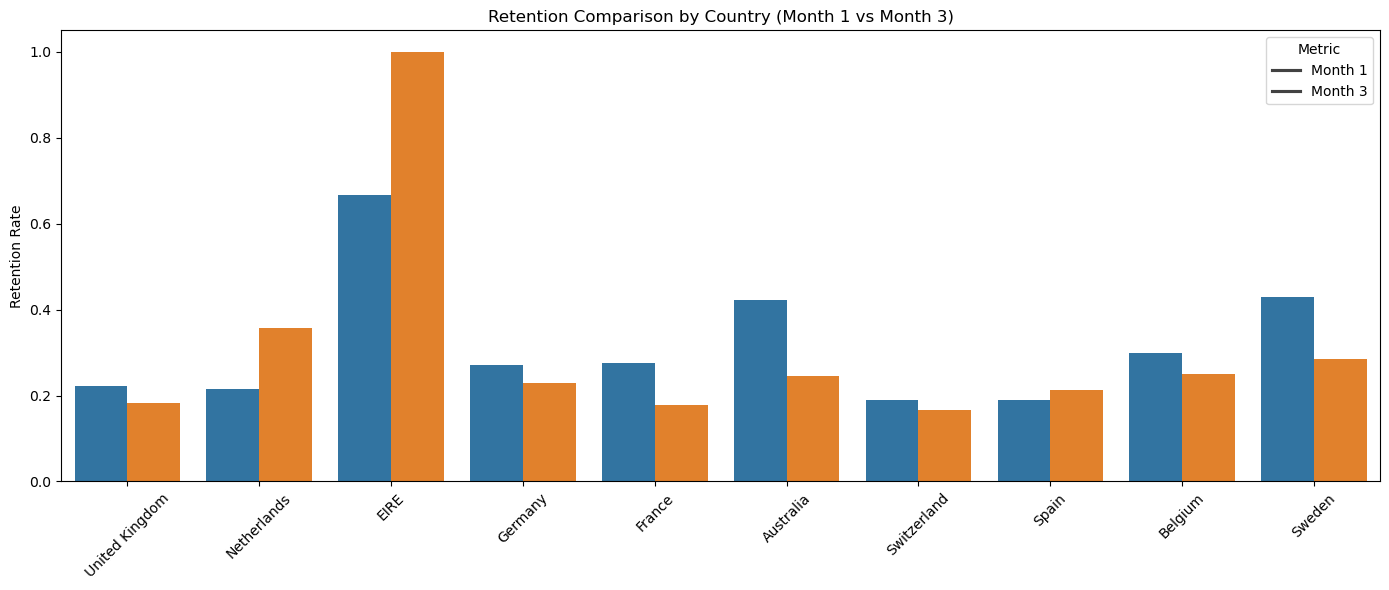

In [146]:
retention_melted = retention_top10.melt(
    id_vars='country',
    value_vars=['month_1', 'month_3'],
    var_name='metric',
    value_name='retention'
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=retention_melted,
    x='country',
    y='retention',
    hue='metric'
)

plt.xticks(rotation=45)
plt.ylabel('Retention Rate')
plt.xlabel('')
plt.title('Retention Comparison by Country (Month 1 vs Month 3)')
plt.legend(title='Metric', labels=['Month 1', 'Month 3'])

plt.tight_layout()
plt.show()

### Retention by Country

**1. Retention varies significantly across countries**
- Month 1 retention:
  - UK: ~22%
  - Germany/France: ~27%
  - Australia/Sweden: ~42%

**Insight:**  
Customer engagement quality differs across markets.


**2. Some smaller markets show stronger early retention**
- Australia: 42% → 24%
- Sweden: 43% → 29%

**Insight:**  
Certain markets attract more engaged customers, despite smaller scale.


**3. UK retention is relatively low**
- Month 1: ~22%
- Month 3: ~18%

**Insight:**  
Despite being the largest market, UK customers are less engaged compared to some smaller countries.


**4. Extreme values in small samples**
- EIRE: 66% → 100%

**Insight:**  
Retention metrics for very small cohorts are unreliable and driven by a few users.

---

### Key Geographic Insight

The business shows a clear trade-off between scale and quality:

- The UK provides scale (users + revenue) but lower engagement
- Smaller countries provide higher-value and more engaged customers but lack scale

**Final Insight:**  
Growth strategy should balance:
- optimizing the core market (UK)
- and expanding high-quality international markets